<a href="https://colab.research.google.com/github/Gauransh185/sales-analysis-python/blob/main/EDA_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data Analyst Project : Retail Performance Analysis: Sales & Profitability Insights**

##Introduction:
This project analyzes the Sample Superstore dataset to evaluate sales, profit margins, and regional trends. The goal is to identify underperforming areas and provide data-driven recommendations for better business decision-making and increased profitability.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("SampleSuperstore.csv")

In [ ]:
print("first 5 rows of the dataset:")
df.head()


first 5 rows of the dataset:


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [ ]:
print(f"the dataset shape is:{df.shape}")

the dataset shape is:(9994, 13)


In [ ]:
print("-----------dataset information-----------")
df.info()

-----------dataset information-----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [ ]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


##Data Understanding :

In this phase, I am exploring the dataset structure to ensure data integrity.

Dataset Shape: The data contains 9,994 rows and 13 columns.

Column Description:
I have selected 5 key columns that are essential for analyzing the business's physical and financial performance:

Region: The broad geographic area (East, West, Central, South) where the transaction occurred.

Category: The type of product sold (e.g., Furniture, Technology).

Sales: The total revenue generated from the transaction.

Profit: The net gain or loss , crucial for identifying underperforming products.

Discount: The price reduction applied, which I will analyze to see if it actually drives more profit or just causes losses.

These columns will help in analyzing profitability across regions and product categories.

Data Types
Ensuring correct data types is vital for accurate calculations:

Numerical (int64/float64): Sales, Quantity, Discount, Profit, and Postal Code.

Categorical (object): Ship Mode, Segment, Category, Region, City, and State.

Observation: Since there are no DateTime columns in this version of the dataset, the analysis will focus on spatial distribution and category-wise performance.

In [ ]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


In [ ]:
df.duplicated().sum()

np.int64(17)

In [ ]:
df[df.duplicated()]

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
950,Standard Class,Home Office,United States,Philadelphia,Pennsylvania,19120,East,Office Supplies,Paper,15.552,3,0.2,5.4432
3406,Standard Class,Home Office,United States,Columbus,Ohio,43229,East,Furniture,Chairs,281.372,2,0.3,-12.0588
3670,Standard Class,Consumer,United States,Salem,Oregon,97301,West,Office Supplies,Paper,10.368,2,0.2,3.6288
4117,Standard Class,Consumer,United States,Los Angeles,California,90036,West,Office Supplies,Paper,19.440,3,0.0,9.3312
4553,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,12.840,3,0.0,5.7780
5905,Same Day,Home Office,United States,San Francisco,California,94122,West,Office Supplies,Labels,41.400,4,0.0,19.8720
6146,Standard Class,Corporate,United States,San Francisco,California,94122,West,Office Supplies,Art,11.760,4,0.0,3.1752
6334,Standard Class,Consumer,United States,New York City,New York,10011,East,Office Supplies,Paper,49.120,4,0.0,23.0864
6357,Standard Class,Corporate,United States,Seattle,Washington,98103,West,Office Supplies,Paper,25.920,4,0.0,12.4416
7608,Standard Class,Consumer,United States,San Francisco,California,94122,West,Office Supplies,Paper,25.920,4,0.0,12.4416


In [ ]:
df=df.drop_duplicates()

In [ ]:
df.shape

(9977, 13)

<Axes: >

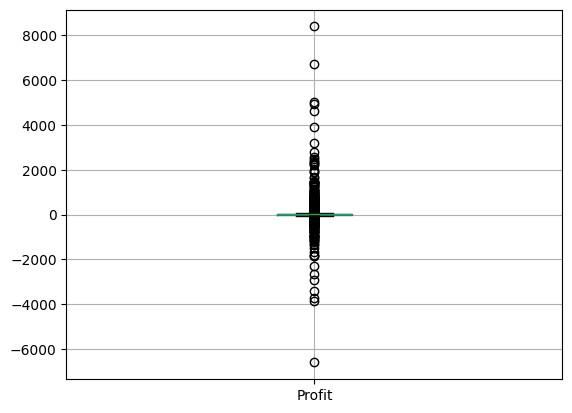

In [ ]:
df.boxplot( column="Profit")

###Key Observations:
-Based on this observation, outliers will not be removed as they represent real business scenarios (extreme profit and loss). Instead, they will be considered carefully during analysis to avoid misleading conclusions.

-Outliers are present on both positive and negative sides, indicating extreme profit and loss cases.

-Large negative outliers indicate significant losses, which may require deeper investigation.

-Most data points are concentrated near zero, suggesting that the majority of transactions generate low profit.

##Exploratory Data Analysis (EDA)

In this section, I analyze sales, profit, and discount patterns across different categories and regions. This helps identify high-performing segments, loss-making areas, and the impact of discount strategies on overall profitability.

Key areas of focus:

-Performance Analysis: Evaluate sales and profit across categories and regions

-Discount Impact: Analyze the relationship between discount and profitability

-Top Contributors: Identify sub-categories contributing the most to revenue

##Category Analysis:

In [ ]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741306.3133
Office Supplies,718735.2440


In [ ]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122364.6608
Furniture,18421.8137


###Key Observations:

-Technology leads in both sales and profit, making it the strongest performing category.

-Furniture generates high sales but low profit, indicating lower margins or higher costs.

-Office Supplies, despite lower sales, achieves better profit than Furniture, suggesting more efficient profitability.

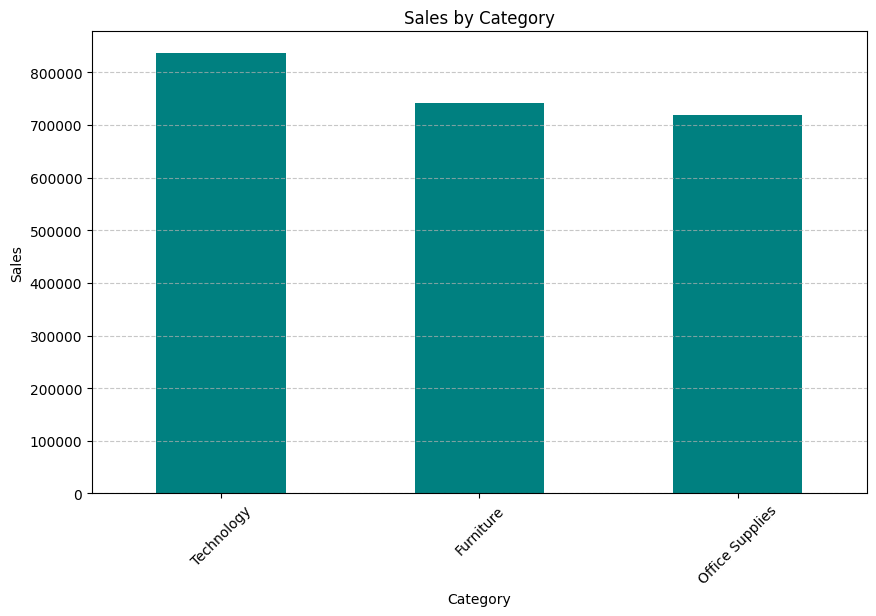

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar',figsize=(10,6),color='teal')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)

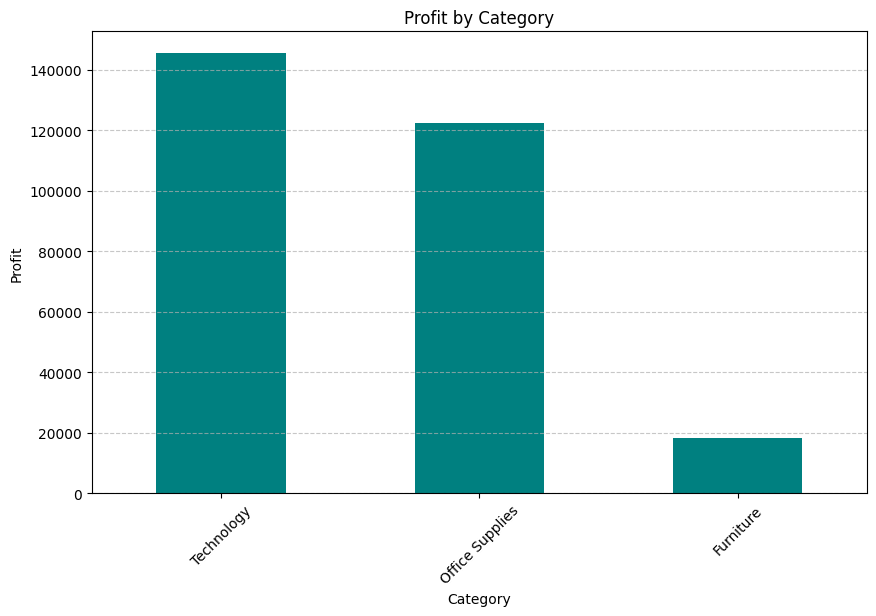

In [ ]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_profit.plot(kind='bar',figsize=(10,6),color='teal')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)

##Regional Analysis:

In [ ]:
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

,Sales
Region,
West,725255.6365
East,678435.1960
Central,500782.8528
South,391721.9050


In [ ]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

,Profit
Region,
West,108329.8079
East,91506.3092
South,46749.4303
Central,39655.8752


###Key Observations : Regional Performance

-West region leads in both sales and profit, making it the strongest performing region.

-East region ranks second in both sales and profit, indicating consistent performance.

-Central region shows moderate sales but the lowest profit, suggesting lower profitability efficiency.

-South region has the lowest sales but higher profit than Central, indicating relatively better profit performance despite lower revenue.

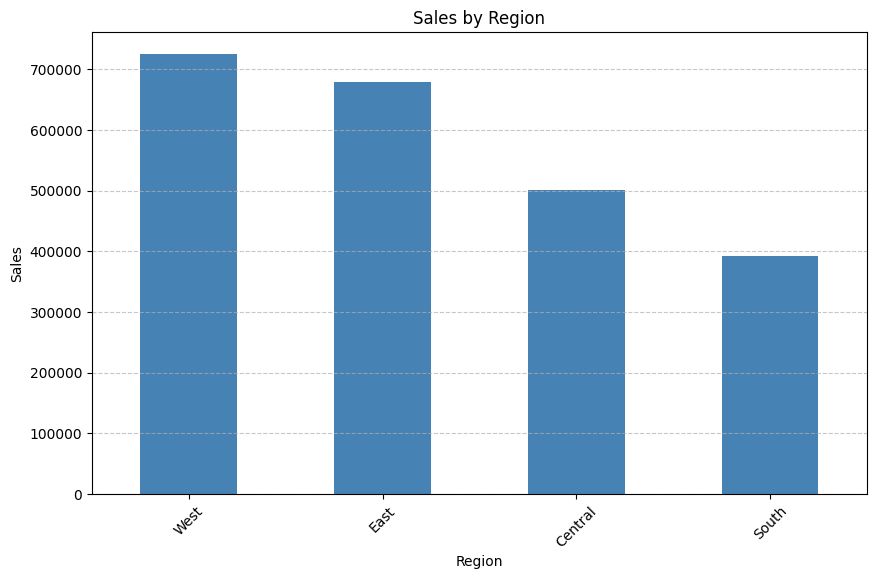

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar',figsize=(10,6),color='steelblue')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)

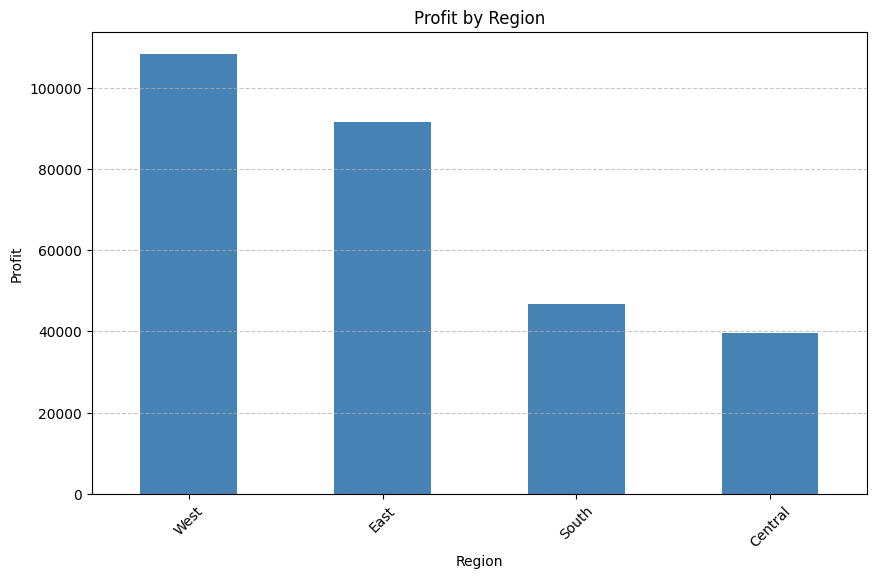

In [ ]:
region_sales = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar',figsize=(10,6),color='steelblue')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)

##Discount vs Profit Analysis:

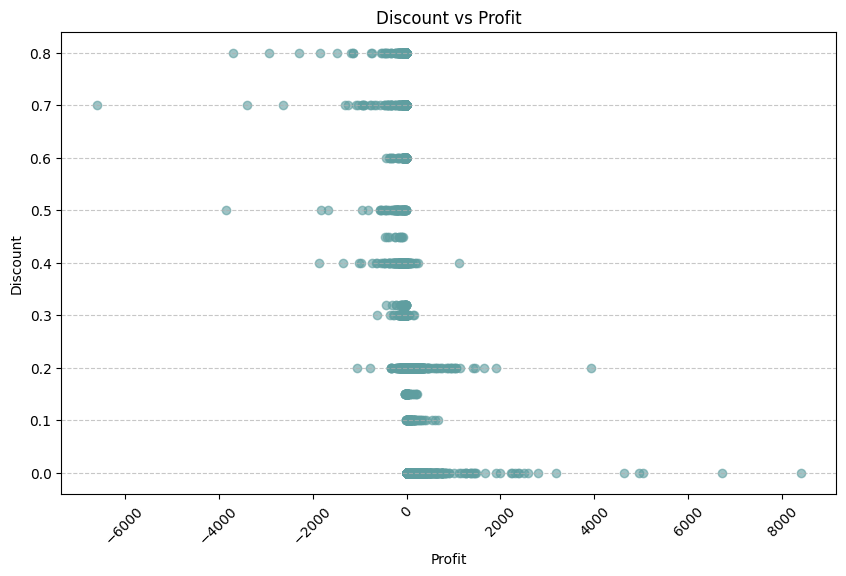

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df['Profit'], df['Discount'], color='cadetblue', alpha=0.6)
plt.title('Discount vs Profit')
plt.xlabel('Profit')
plt.ylabel('Discount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

###Key Observations:
-There is a negative relationship between discount and profit, indicating that higher discounts tend to reduce profitability.

-High discount levels are frequently associated with losses, suggesting that excessive discounting harms business performance.

-Lower discount ranges show higher and more consistent profits, indicating better pricing efficiency.

###Recommendations:
-The company should avoid excessive discounting, as higher discounts are strongly associated with losses.

-Discount strategies should be optimized to balance sales growth and profitability, focusing on lower discount ranges where profit remains stable.

##Top 10 Sub-Categories by Profit:

In [ ]:
df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,33944.2395
Binders,30228.0003
Chairs,26567.1278
Storage,21278.8264
Appliances,18138.0054
Furnishings,13052.7230


###Key Observations:
-Copiers generate the highest profit among all sub-categories, making them the most profitable segment.

-Phones and Accessories also contribute significantly to profit, indicating strong performance in these sub-categories.

-Sub-categories such as Paper, Binders, and Chairs provide moderate profit, contributing steadily to overall profitability.

-Lower-ranked sub-categories like Furnishings and Envelopes contribute comparatively less profit, indicating weaker profitability.

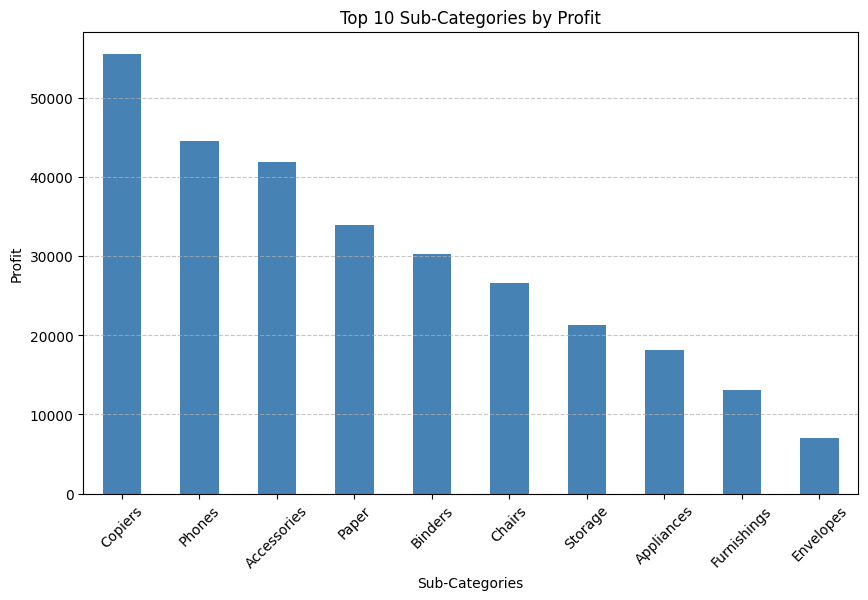

In [ ]:
sub_categ = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)
sub_categ.plot(kind='bar',figsize=(10,6),color='steelblue')
plt.title('Top 10 Sub-Categories by Profit')
plt.xlabel('Sub-Categories')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.grid(axis='y',linestyle='--',alpha=0.7)

##Conclusion:

This project analyzed the Sample Superstore dataset to evaluate sales performance, profitability, and discount impact across different categories and regions. The analysis revealed that Technology is the strongest performing category in both sales and profit, while the West region contributes the highest overall business performance.

The study also showed that some categories, such as Furniture, generate relatively high sales but lower profit, indicating weaker profitability efficiency. In contrast, Office Supplies demonstrated better profitability despite lower sales volume.

Additionally, the discount analysis identified a negative relationship between discount levels and profit, suggesting that excessive discounting can significantly reduce profitability. These insights can help businesses optimize pricing strategies, improve regional performance, and focus on high-performing product segments for better decision-making and long-term growth.

##Note:
The analysis includes all data points, including outliers, as they represent real business scenarios. However, extreme values may slightly influence aggregated results.